<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/lecture_notes/notebooks/14_Domain_Specific_Applications.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 14 실습: 금융·경영·환경 데이터 응용
**Notebook:** `14_Domain_Specific_Applications.ipynb`

## 실습 목표 (Learning Objectives)
이 실습에서는 다음을 수행합니다.

1. 금융, 경영, 환경 데이터가 각각 어떤 시계열적 특성을 가지는지 비교합니다.
2. 도메인별로 적절한 전처리 전략이 왜 다른지 이해합니다.
3. 금융 데이터에서는 가격(level) 대신 로그수익률(return)과 변동성(volatility)을 다룹니다.
4. 경영 데이터에서는 휴일·프로모션과 같은 이벤트 효과를 반영한 예측을 수행합니다.
5. 환경 데이터에서는 결측치 보간과 주간 계절성 처리가 왜 중요한지 확인합니다.
6. 각 도메인에 맞는 대표 모형 또는 분석 흐름을 간단히 구현합니다.
7. “좋은 시계열 모델”이 아니라 **도메인에 맞는 시계열 모델**을 선택하는 사고방식을 익힙니다.

---

## 왜 이 실습이 중요한가?
같은 시계열 분석이라도, 데이터가 어떤 현실을 반영하는지에 따라 전처리와 해석의 기준이 달라집니다.

- 금융 데이터는 가격 자체보다 수익률과 변동성의 군집이 중요합니다.
- 경영 데이터는 휴일, 프로모션, 요일 효과가 핵심적인 설명 변수입니다.
- 환경 데이터는 센서 결측, 주말/평일 차이, 계절성이 중요한 경우가 많습니다.

따라서 이 장의 핵심은 하나의 알고리즘을 반복하는 것이 아니라,  
**“도메인이 다르면 질문도 달라지고, 전처리도 달라지고, 좋은 모델의 기준도 달라진다”**는 점을 실습으로 체감하는 데 있습니다.


In [1]:
# ============================================
# 1. 공통 라이브러리 불러오기
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

from IPython.display import display


## 1. 시각화 기본 설정
이번 버전도 Colab 호환성을 위해 **그래프 텍스트는 영어**로 출력합니다.  
마크다운 셀과 코드 주석은 한글로 유지합니다.


In [2]:
# ============================================
# 2. 시각화 기본 설정
# ============================================

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.unicode_minus"] = False


# Part A. 금융 시계열 응용

## 왜 금융 데이터는 다르게 다뤄야 하는가?
주가나 환율 같은 금융 시계열은 대체로 다음 특징을 가집니다.

- 가격 수준(level)은 비정상적일 가능성이 높다.
- 로그수익률은 상대적으로 더 안정적이다.
- 큰 변동 뒤에 또 큰 변동이 오는 **변동성 군집(Volatility Clustering)** 이 자주 나타난다.

따라서 금융 응용에서는 가격을 그대로 회귀하는 것보다,  
**수익률 변환**과 **변동성 모델링**이 핵심이 됩니다.


## 2. yfinance 준비
이번 금융 파트에서는 **TSLA 일별 가격 데이터**를 사용합니다.  
설치되어 있지 않다면 자동으로 설치합니다.


In [3]:
# ============================================
# 3. yfinance 설치 및 임포트
# ============================================

try:
    import yfinance as yf
    print("yfinance is already installed.")
except ImportError:
    print("Installing yfinance...")
    !pip -q install yfinance
    import yfinance as yf
    print("yfinance installation completed.")


yfinance is already installed.


In [4]:
# ============================================
# 4. TSLA 데이터 다운로드
# ============================================

ticker = "TSLA"
start_date = "2018-01-01"
end_date = "2024-12-31"

fin_df = yf.download(
    ticker,
    start=start_date,
    end=end_date,
    auto_adjust=False,
    progress=False
)

print("Raw shape:", fin_df.shape)
display(fin_df.head())


Raw shape: (1760, 6)


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,,
2018-01-02,21.368668,21.368668,21.474001,20.733334,20.799999,65283000
2018-01-03,21.150000,21.150000,21.683332,21.036667,21.400000,67822500
2018-01-04,20.974667,20.974667,21.236668,20.378668,20.858000,149194500
2018-01-05,21.105333,21.105333,21.149332,20.799999,21.108000,68868000
2018-01-08,22.427334,22.427334,22.468000,21.033333,21.066668,147891000


## 3. MultiIndex 컬럼을 고려한 종가 추출
`yfinance`는 환경에 따라 MultiIndex columns를 반환할 수 있습니다.  
따라서 안전하게 종가를 추출하는 helper 함수를 사용합니다.


In [5]:
# ============================================
# 5. MultiIndex-safe close series 추출
# ============================================

def get_close_series(df, ticker):
    if isinstance(df.columns, pd.MultiIndex):
        return df[("Close", ticker)].copy()
    return df["Close"].copy()

tsla_close = get_close_series(fin_df, ticker)
tsla_close.name = "Close"

display(tsla_close.head())


,Close
Date,
2018-01-02,21.368668
2018-01-03,21.150000
2018-01-04,20.974667
2018-01-05,21.105333
2018-01-08,22.427334


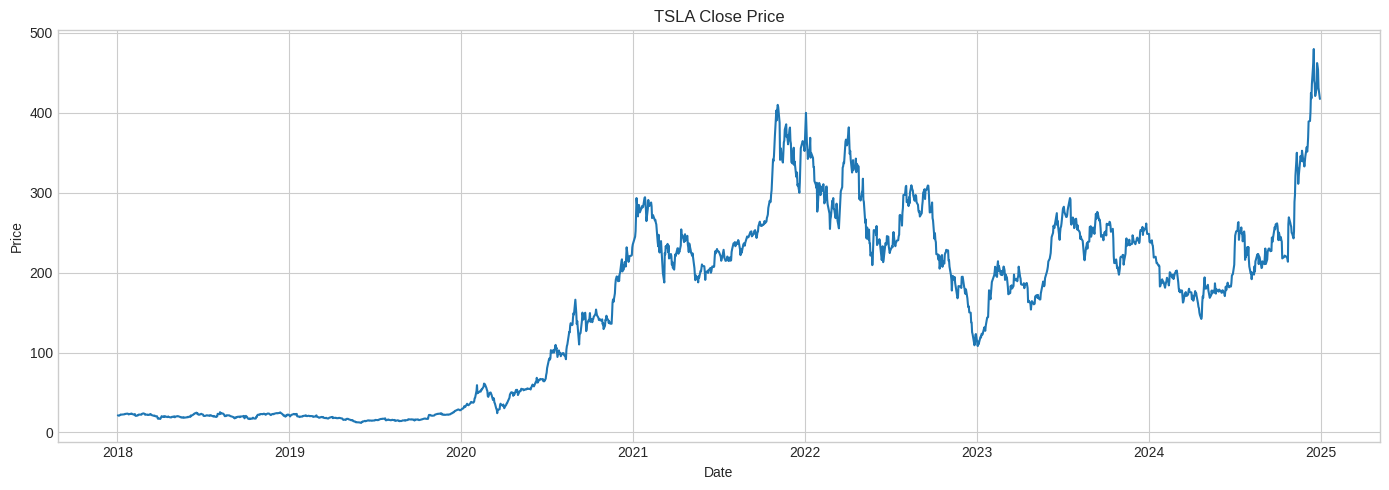

In [6]:
# ============================================
# 6. 가격 수준 플롯
# ============================================

plt.figure(figsize=(14, 5))
plt.plot(tsla_close.index, tsla_close, linewidth=1.5)

plt.title("TSLA Close Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.tight_layout()
plt.show()


## 4. 로그수익률 변환
금융 데이터에서는 가격 자체보다 **로그수익률(log return)** 을 자주 사용합니다.

이유는 다음과 같습니다.

- 가격 수준은 단위근을 가질 수 있다.
- 수익률은 상대적으로 정상성에 더 가까울 수 있다.
- 자산 간 비교가 더 쉽다.


In [7]:
# ============================================
# 7. 로그수익률 생성
# ============================================

fin_df["Log_Return"] = np.log(tsla_close / tsla_close.shift(1))
display(fin_df[["Log_Return"]].dropna().head())


Price,Log_Return
Ticker,
Date,
2018-01-03,-0.010286
2018-01-04,-0.008325
2018-01-05,0.006210
2018-01-08,0.060755
2018-01-09,-0.008118


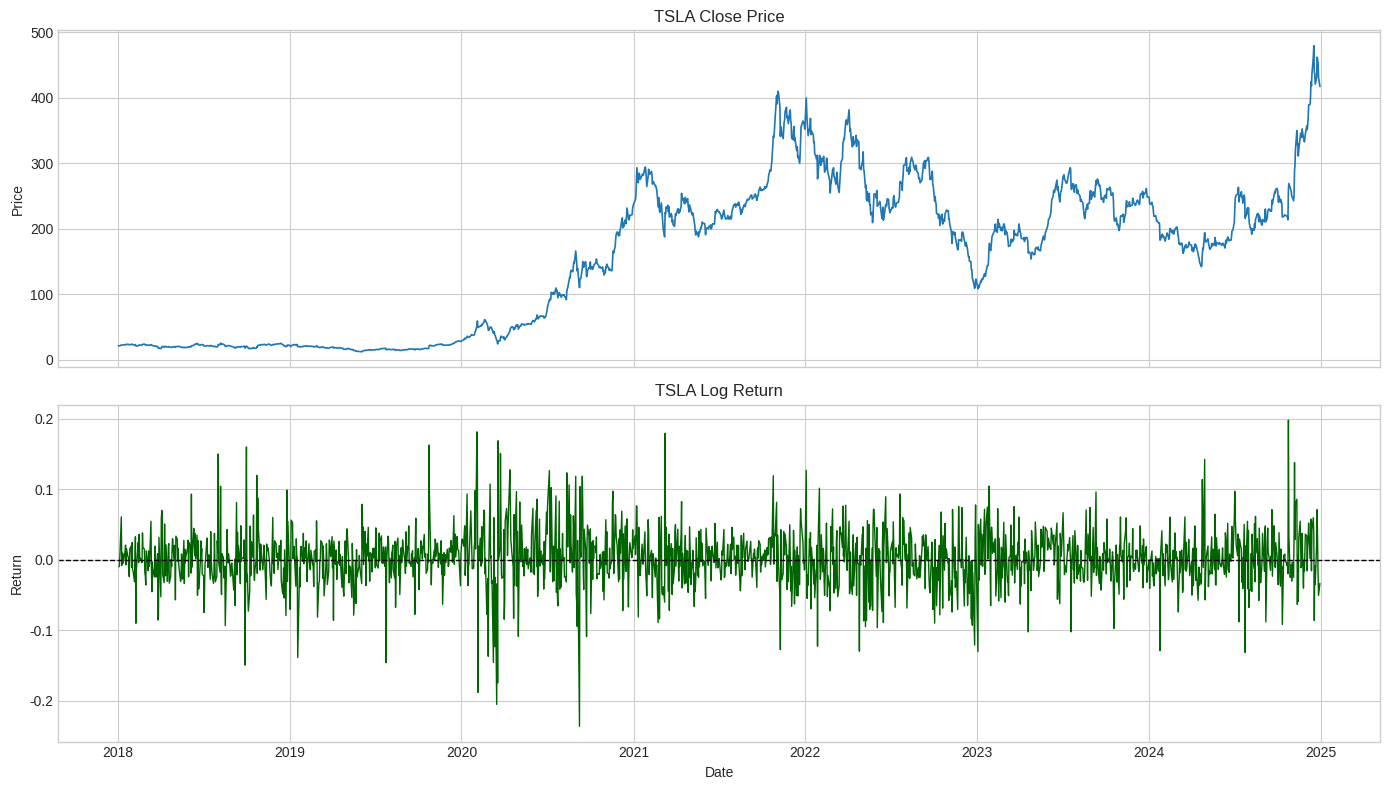

In [8]:
# ============================================
# 8. 가격 vs 로그수익률 비교 플롯
# ============================================

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(tsla_close.index, tsla_close, linewidth=1.2)
axes[0].set_title("TSLA Close Price")
axes[0].set_ylabel("Price")

axes[1].plot(fin_df.index, fin_df["Log_Return"], linewidth=1.0, color="darkgreen")
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("TSLA Log Return")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Return")

plt.tight_layout()
plt.show()


## 5. 가격과 수익률의 정상성 비교
아래 ADF 검정은 “가격 수준”과 “로그수익률”을 비교하는 가장 기본적인 실습입니다.  
사용자 환경에 따라 `yfinance` 컬럼 구조가 MultiIndex일 수 있으므로, 종가 접근은 안전한 패턴을 유지합니다.


In [9]:
# ============================================
# 9. ADF 검정 함수
# ============================================

from statsmodels.tsa.stattools import adfuller

def adf_report(series, name="Series"):
    series = pd.Series(series).dropna()
    result = adfuller(series, autolag="AIC")
    print(f"===== {name} =====")
    print("ADF Statistic :", round(result[0], 4))
    print("ADF p-value   :", round(result[1], 4))
    print("-" * 40)


In [10]:
# ============================================
# 10. 가격과 수익률의 ADF 검정
# ============================================

# yfinance 결과가 MultiIndex일 수 있으므로 안전한 접근을 사용
if isinstance(fin_df.columns, pd.MultiIndex):
    adf_report(fin_df[('Close', 'TSLA')].dropna(), "TSLA Close Price")
else:
    adf_report(fin_df["Close"].dropna(), "TSLA Close Price")

adf_report(fin_df["Log_Return"].dropna(), "TSLA Log Return")


===== TSLA Close Price =====
ADF Statistic : -1.0559
ADF p-value   : 0.7323
----------------------------------------
===== TSLA Log Return =====
ADF Statistic : -42.5327
ADF p-value   : 0.0
----------------------------------------


## 6. GARCH(1,1)으로 변동성 직관 보기
금융 도메인에서는 수익률 평균보다 **조건부 분산(conditional variance)** 이 더 중요한 경우가 많습니다.  
여기서는 `arch` 패키지가 있으면 간단한 GARCH(1,1)을 적합합니다.

> 참고  
> 이 실습의 목적은 GARCH를 완전히 마스터하는 것이 아니라,  
> “금융 데이터에서는 예측 대상이 수준이 아니라 변동성일 수도 있다”는 점을 확인하는 데 있습니다.


In [11]:
# ============================================
# 11. arch 설치 및 GARCH(1,1) 적합
# ============================================

try:
    from arch import arch_model
    print("arch is already installed.")
except ImportError:
    print("Installing arch...")
    !pip -q install arch
    from arch import arch_model
    print("arch installation completed.")

ret = fin_df["Log_Return"].dropna() * 100  # scale up for GARCH stability

garch = arch_model(ret, mean="Constant", vol="GARCH", p=1, q=1)
garch_res = garch.fit(disp="off")

print(garch_res.summary())


Installing arch...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 15.2 MB/s eta 0:00:00
arch installation completed.
                     Constant Mean - GARCH Model Results                      
Dep. Variable:             Log_Return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -4863.35
Distribution:                  Normal   AIC:                           9734.70
Method:            Maximum Likelihood   BIC:                           9756.59
                                        No. Observations:                 1759
Date:                Sun, Mar 15 2026   Df Residuals:                     1758
Time:                        02:58:44   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
--------

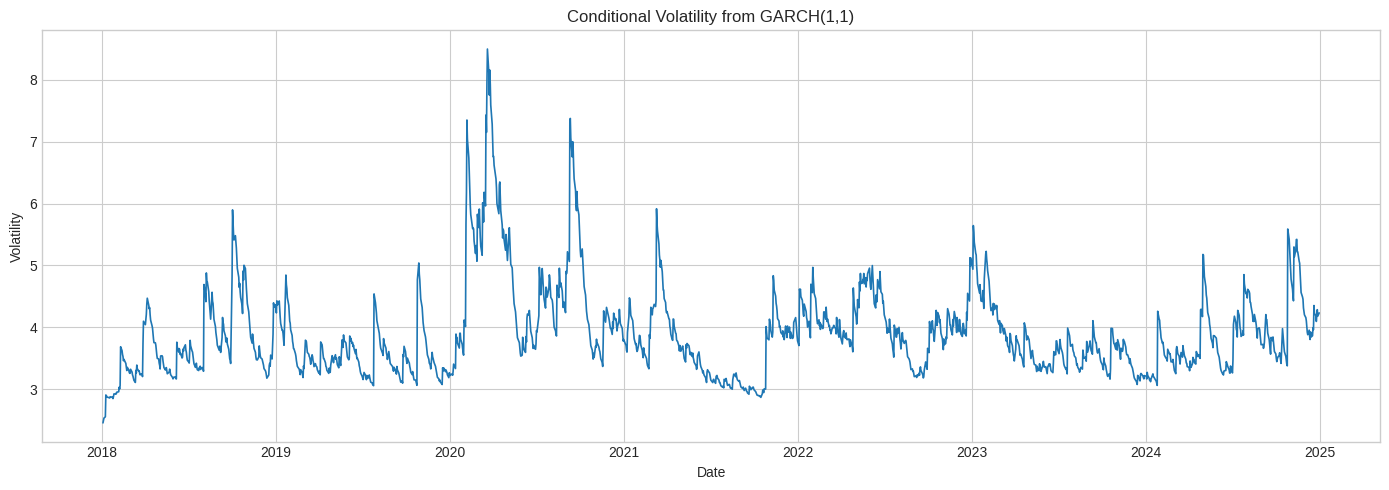

In [12]:
# ============================================
# 12. 조건부 변동성 플롯
# ============================================

conditional_vol = garch_res.conditional_volatility

plt.figure(figsize=(14, 5))
plt.plot(conditional_vol.index, conditional_vol, linewidth=1.2)

plt.title("Conditional Volatility from GARCH(1,1)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.tight_layout()
plt.show()


# Part B. 경영·수요 데이터 응용

## 왜 경영 데이터는 휴일과 이벤트를 고려해야 하는가?
경영 및 수요 데이터는 종종 사람의 생활 패턴과 운영 캘린더에 지배됩니다.

예를 들어,
- 요일별 수요 차이
- 월말 / 분기말 효과
- 프로모션
- 공휴일 및 명절
- 구조변화(팬데믹, 정책 변화)

가 예측 정확도에 큰 영향을 줍니다.

따라서 이 도메인에서는 “추세와 계절성만 보는 것”보다  
**휴일과 이벤트를 모형에 어떻게 넣을 것인가**가 핵심이 됩니다.


## 7. synthetic retail sales data 생성
온라인에서도 안정적으로 실행할 수 있도록, 이 파트는 synthetic retail sales data를 사용합니다.

구조는 다음과 같습니다.

- 완만한 추세
- 주간 요일 패턴
- 연말 seasonality
- 특정 holiday / promotion 효과


In [13]:
# ============================================
# 13. Synthetic daily retail sales 생성
# ============================================

np.random.seed(42)

biz_dates = pd.date_range(start="2021-01-01", end="2024-12-31", freq="D")
n_biz = len(biz_dates)
tt = np.arange(n_biz)

trend = 200 + 0.03 * tt

weekday = biz_dates.weekday
weekday_effect = np.select(
    [
        weekday == 0,
        weekday == 1,
        weekday == 2,
        weekday == 3,
        weekday == 4,
        weekday == 5,
        weekday == 6
    ],
    [-10, -5, 0, 5, 15, 25, -20],
    default=0
)

day_of_year = biz_dates.dayofyear.values
annual_effect = 8 * np.sin(2 * np.pi * day_of_year / 365.25)

sales = trend + weekday_effect + annual_effect + np.random.normal(0, 6, n_biz)

retail_df = pd.DataFrame({"ds": biz_dates, "y": sales})

# holiday / promotion event
holiday_dates = pd.to_datetime([
    "2021-11-26", "2021-12-24",
    "2022-11-25", "2022-12-24",
    "2023-11-24", "2023-12-24",
    "2024-11-29", "2024-12-24"
])

for d in holiday_dates:
    if d in set(retail_df["ds"]):
        retail_df.loc[retail_df["ds"] == d, "y"] += 45

display(retail_df.head())


,ds,y
0,2021-01-01,218.117898
1,2021-01-02,224.475599
2,2021-01-03,184.358806
3,2021-01-04,199.778222
4,2021-01-05,194.402329


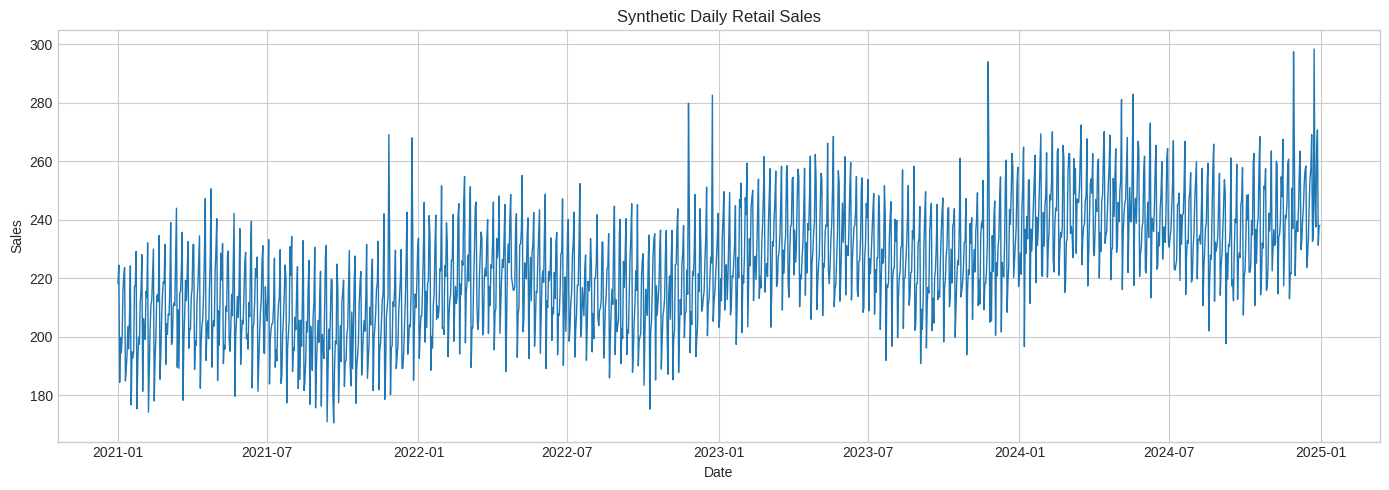

In [14]:
# ============================================
# 14. Retail sales plot
# ============================================

plt.figure(figsize=(14, 5))
plt.plot(retail_df["ds"], retail_df["y"], linewidth=1.0)

plt.title("Synthetic Daily Retail Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()


## 8. Prophet 준비
Prophet은 경영·수요 데이터처럼

- 추세
- 여러 주기의 계절성
- holiday effect

를 함께 다루기 편한 실무형 도구입니다.

> 참고  
> Prophet 설치는 Colab에서 몇 분 걸릴 수 있습니다.


In [15]:
# ============================================
# 15. prophet 설치 및 임포트
# ============================================

try:
    from prophet import Prophet
    print("Prophet is already installed.")
except ImportError:
    print("Installing prophet...")
    !pip -q install prophet
    from prophet import Prophet
    print("Prophet installation completed.")


Prophet is already installed.


## 9. Holiday dataframe 만들기
Prophet은 `holidays` 데이터프레임을 통해 이벤트 효과를 모형에 명시적으로 주입할 수 있습니다.


In [16]:
# ============================================
# 16. Holiday dataframe 생성
# ============================================

holidays_df = pd.DataFrame({
    "holiday": ["promo"] * len(holiday_dates),
    "ds": holiday_dates,
    "lower_window": 0,
    "upper_window": 0
})

display(holidays_df.head())


,holiday,ds,lower_window,upper_window
0,promo,2021-11-26,0,0
1,promo,2021-12-24,0,0
2,promo,2022-11-25,0,0
3,promo,2022-12-24,0,0
4,promo,2023-11-24,0,0


## 10. Train / Test split
마지막 90일을 테스트 구간으로 둡니다.  
Prophet도 결국 예측 모형이므로, out-of-sample 비교가 필요합니다.


In [17]:
# ============================================
# 17. Train / Test split for retail data
# ============================================

biz_test_size = 90

biz_train = retail_df.iloc[:-biz_test_size].copy()
biz_test = retail_df.iloc[-biz_test_size:].copy()

print("Train size:", len(biz_train))
print("Test size :", len(biz_test))


Train size: 1371
Test size : 90


## 11. Holiday를 넣지 않은 Prophet
먼저 이벤트 정보를 넣지 않은 기본 Prophet을 적합합니다.


In [18]:
# ============================================
# 18. Prophet without holidays
# ============================================

prophet_base = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

prophet_base.fit(biz_train)

future_base = prophet_base.make_future_dataframe(periods=biz_test_size, freq="D")
forecast_base = prophet_base.predict(future_base)

forecast_base_test = forecast_base.set_index("ds").loc[biz_test["ds"], "yhat"].values
display(forecast_base[["ds", "yhat", "trend"]].tail())


,ds,yhat,trend
1456,2024-12-27,261.131769,244.344782
1457,2024-12-28,270.395283,244.369935
1458,2024-12-29,224.677955,244.395089
1459,2024-12-30,235.725253,244.420242
1460,2024-12-31,239.653884,244.445395


## 12. Holiday를 넣은 Prophet
이제 holiday dataframe을 함께 넣어 같은 예측을 수행합니다.  
이 비교를 통해 이벤트 효과를 반영하는 것이 실제 예측에 도움이 되는지 볼 수 있습니다.


In [19]:
# ============================================
# 19. Prophet with holidays
# ============================================

prophet_holiday = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    holidays=holidays_df
)

prophet_holiday.fit(biz_train)

future_holiday = prophet_holiday.make_future_dataframe(periods=biz_test_size, freq="D")
forecast_holiday = prophet_holiday.predict(future_holiday)

forecast_holiday_test = forecast_holiday.set_index("ds").loc[biz_test["ds"], "yhat"].values
display(forecast_holiday[["ds", "yhat", "trend"]].tail())


,ds,yhat,trend
1456,2024-12-27,258.185944,243.973901
1457,2024-12-28,268.179247,243.998623
1458,2024-12-29,222.518751,244.023344
1459,2024-12-30,233.874908,244.048066
1460,2024-12-31,237.900879,244.072788


In [20]:
# ============================================
# 20. Prophet 예측 성능 비교
# ============================================

from sklearn.metrics import mean_absolute_error, mean_squared_error

def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def evaluate_forecast(y_true, y_pred, model_name="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape_value = mape(y_true, y_pred)
    return pd.DataFrame({
        "Model": [model_name],
        "MAE": [mae],
        "RMSE": [rmse],
        "MAPE": [mape_value]
    })

eval_prophet_base = evaluate_forecast(biz_test["y"], forecast_base_test, "Prophet Base")
eval_prophet_holiday = evaluate_forecast(biz_test["y"], forecast_holiday_test, "Prophet + Holidays")

prophet_eval = pd.concat([eval_prophet_base, eval_prophet_holiday], ignore_index=True)
display(prophet_eval.sort_values("MAPE"))


,Model,MAE,RMSE,MAPE
1,Prophet + Holidays,5.465689,6.593721,2.258120
0,Prophet Base,6.041278,9.824088,2.429875


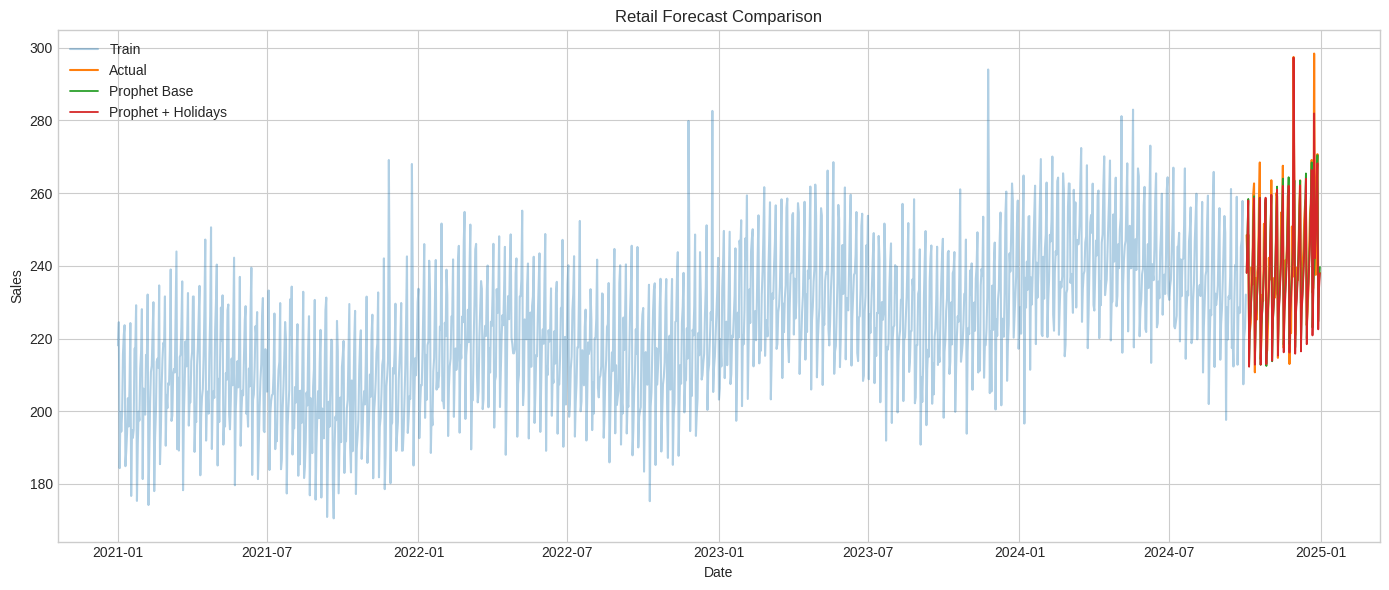

In [21]:
# ============================================
# 21. Retail forecast comparison plot
# ============================================

plt.figure(figsize=(14, 6))
plt.plot(biz_train["ds"], biz_train["y"], label="Train", alpha=0.35)
plt.plot(biz_test["ds"], biz_test["y"], label="Actual", linewidth=1.5)
plt.plot(biz_test["ds"], forecast_base_test, label="Prophet Base", linewidth=1.3)
plt.plot(biz_test["ds"], forecast_holiday_test, label="Prophet + Holidays", linewidth=1.3)

plt.title("Retail Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()


# Part C. 환경 데이터 응용

## 왜 환경 데이터는 결측과 주기 처리가 중요한가?
환경 및 공공 데이터는 종종 다음 특징을 가집니다.

- 센서 결측치가 자주 발생함
- 주말/평일 패턴이 존재할 수 있음
- 기상 또는 계절 요인의 반복성이 큼
- 측정 시스템 문제로 갑작스러운 공백이 생길 수 있음

따라서 이 도메인에서는 sophisticated model 이전에  
**시간 인덱스 유지, 결측 처리, 주간/계절 주기 반영**이 매우 중요합니다.


## 13. synthetic PM10-style environmental data 생성
온라인 재현성을 위해 이 파트는 synthetic daily PM10-like series를 사용합니다.

구조는 다음과 같습니다.

- 계절성(겨울 높고 여름 낮음)
- 주간 패턴(평일 높고 주말 낮음)
- 노이즈
- 일부 무작위 결측
- 연속 결측 구간


In [22]:
# ============================================
# 22. Synthetic environmental series 생성
# ============================================

np.random.seed(7)

env_dates = pd.date_range(start="2022-01-01", end="2024-12-31", freq="D")
n_env = len(env_dates)
tt_env = np.arange(n_env)

annual = 18 + 10 * np.cos(2 * np.pi * tt_env / 365.25)
weekday_env = env_dates.weekday
weekly_effect = np.where(weekday_env < 5, 4, -3)

pm10 = annual + weekly_effect + np.random.normal(0, 3, n_env)

env_df = pd.DataFrame({"date": env_dates, "PM10": pm10}).set_index("date")

# 랜덤 결측
random_missing_idx = np.random.choice(np.arange(n_env), size=40, replace=False)
env_df.iloc[random_missing_idx, 0] = np.nan

# 연속 결측 구간
env_df.loc["2023-08-10":"2023-08-20", "PM10"] = np.nan

display(env_df.head())


,PM10
date,
2022-01-01,30.071577
2022-01-02,23.600708
2022-01-03,32.092543
2022-01-04,33.209235
2022-01-05,29.609566


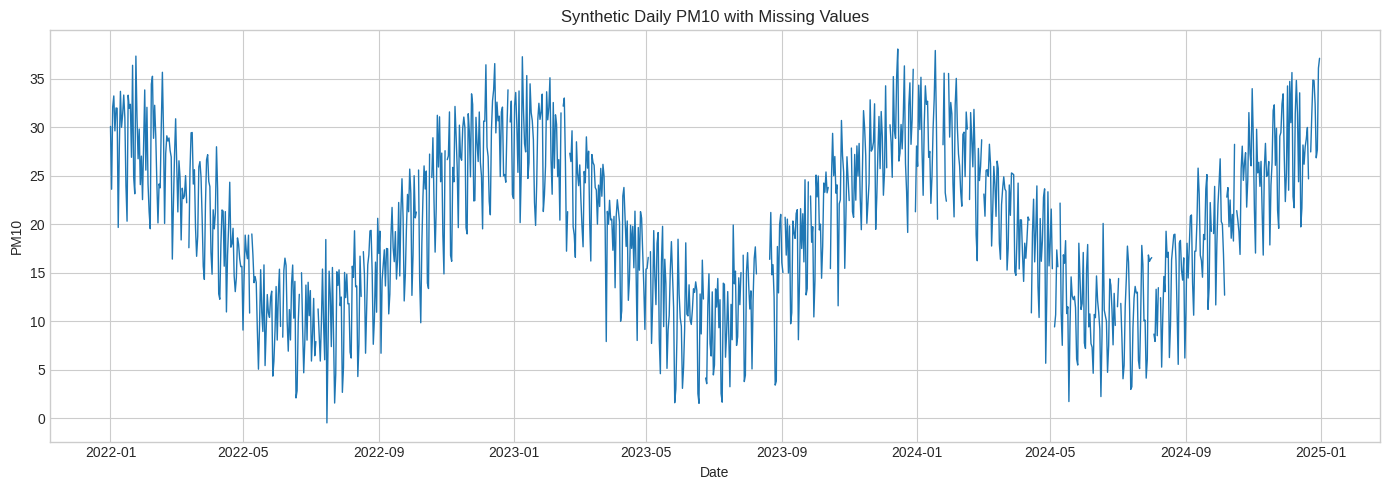

In [23]:
# ============================================
# 23. 결측 포함 원시 PM10 플롯
# ============================================

plt.figure(figsize=(14, 5))
plt.plot(env_df.index, env_df["PM10"], linewidth=1.0)

plt.title("Synthetic Daily PM10 with Missing Values")
plt.xlabel("Date")
plt.ylabel("PM10")
plt.tight_layout()
plt.show()


## 14. 결측치 확인과 보간
환경 데이터에서는 단순 `dropna()`로 삭제하면 시간축의 연속성이 깨질 수 있습니다.  
따라서 먼저 결측 규모를 확인하고, 시간 보간(time interpolation)을 수행합니다.


In [24]:
# ============================================
# 24. 결측 개수와 시간 보간
# ============================================

print("Missing values before interpolation:", env_df["PM10"].isna().sum())

env_interp = env_df.copy()
env_interp["PM10_interp"] = env_interp["PM10"].interpolate(method="time")

print("Missing values after interpolation:", env_interp["PM10_interp"].isna().sum())
display(env_interp.head())


Missing values before interpolation: 50
Missing values after interpolation: 0


,PM10,PM10_interp
date,,
2022-01-01,30.071577,30.071577
2022-01-02,23.600708,23.600708
2022-01-03,32.092543,32.092543
2022-01-04,33.209235,33.209235
2022-01-05,29.609566,29.609566


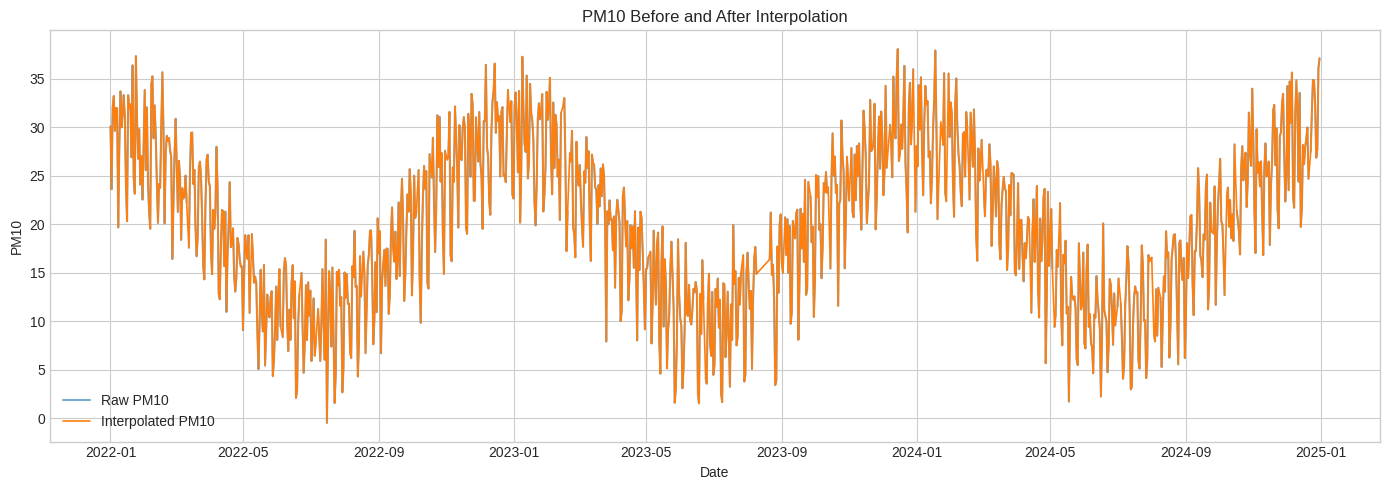

In [25]:
# ============================================
# 25. 보간 전후 비교 플롯
# ============================================

plt.figure(figsize=(14, 5))
plt.plot(env_df.index, env_df["PM10"], label="Raw PM10", alpha=0.6)
plt.plot(env_interp.index, env_interp["PM10_interp"], label="Interpolated PM10", linewidth=1.2)

plt.title("PM10 Before and After Interpolation")
plt.xlabel("Date")
plt.ylabel("PM10")
plt.legend()
plt.tight_layout()
plt.show()


## 15. 주말/평일 효과 만들기
환경 데이터에서는 교통량·공장 가동 등의 차이로 weekday effect가 나타날 수 있습니다.  
따라서 간단한 외생변수로 `is_weekend`를 추가합니다.


In [26]:
# ============================================
# 26. Weekend indicator 생성
# ============================================

env_interp["is_weekend"] = (env_interp.index.weekday >= 5).astype(int)
display(env_interp.head())


,PM10,PM10_interp,is_weekend
date,,,
2022-01-01,30.071577,30.071577,1
2022-01-02,23.600708,23.600708,1
2022-01-03,32.092543,32.092543,0
2022-01-04,33.209235,33.209235,0
2022-01-05,29.609566,29.609566,0


## 16. Train / Test split
마지막 60일을 테스트 구간으로 둡니다.


In [27]:
# ============================================
# 27. Train / Test split for environmental series
# ============================================

env_test_size = 60

env_train = env_interp.iloc[:-env_test_size].copy()
env_test = env_interp.iloc[-env_test_size:].copy()

print("Train size:", len(env_train))
print("Test size :", len(env_test))


Train size: 1036
Test size : 60


## 17. SARIMAX with weekly seasonality
여기서는 7일 주기(weekly seasonality)를 반영한 간단한 SARIMAX를 사용합니다.  
또한 `is_weekend`를 외생변수로 넣습니다.


In [28]:
# ============================================
# 28. SARIMAX fit for environmental data
# ============================================

from statsmodels.tsa.statespace.sarimax import SARIMAX

env_model = SARIMAX(
    env_train["PM10_interp"],
    exog=env_train[["is_weekend"]],
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print(env_model.summary())


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                       PM10_interp   No. Observations:                 1036
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 7)   Log Likelihood               -2646.476
Date:                           Sun, 15 Mar 2026   AIC                           5304.952
Time:                                   02:58:58   BIC                           5334.558
Sample:                               01-01-2022   HQIC                          5316.190
                                    - 11-01-2024                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
is_weekend    14.5525   1006.397      0.014      0.988   -1957.950    1987.055
ar.L1          0.9959      0.003    359.381

## 18. Naive baseline과 비교
환경 데이터에서도 복잡한 모델은 baseline과 비교되어야 합니다.  
여기서는 직전값 유지(naive forecast)를 기준선으로 둡니다.


In [29]:
# ============================================
# 29. Environmental naive baseline
# ============================================

env_naive = pd.Series(env_train["PM10_interp"].iloc[-1], index=env_test.index)

env_forecast = env_model.get_forecast(
    steps=len(env_test),
    exog=env_test[["is_weekend"]]
).predicted_mean

eval_env_naive = evaluate_forecast(env_test["PM10_interp"], env_naive, "Naive")
eval_env_sarimax = evaluate_forecast(env_test["PM10_interp"], env_forecast, "SARIMAX + Weekend")

env_eval = pd.concat([eval_env_naive, eval_env_sarimax], ignore_index=True)
display(env_eval.sort_values("RMSE"))


,Model,MAE,RMSE,MAPE
1,SARIMAX + Weekend,3.529867,4.347747,12.423677
0,Naive,4.317115,5.202926,17.601168


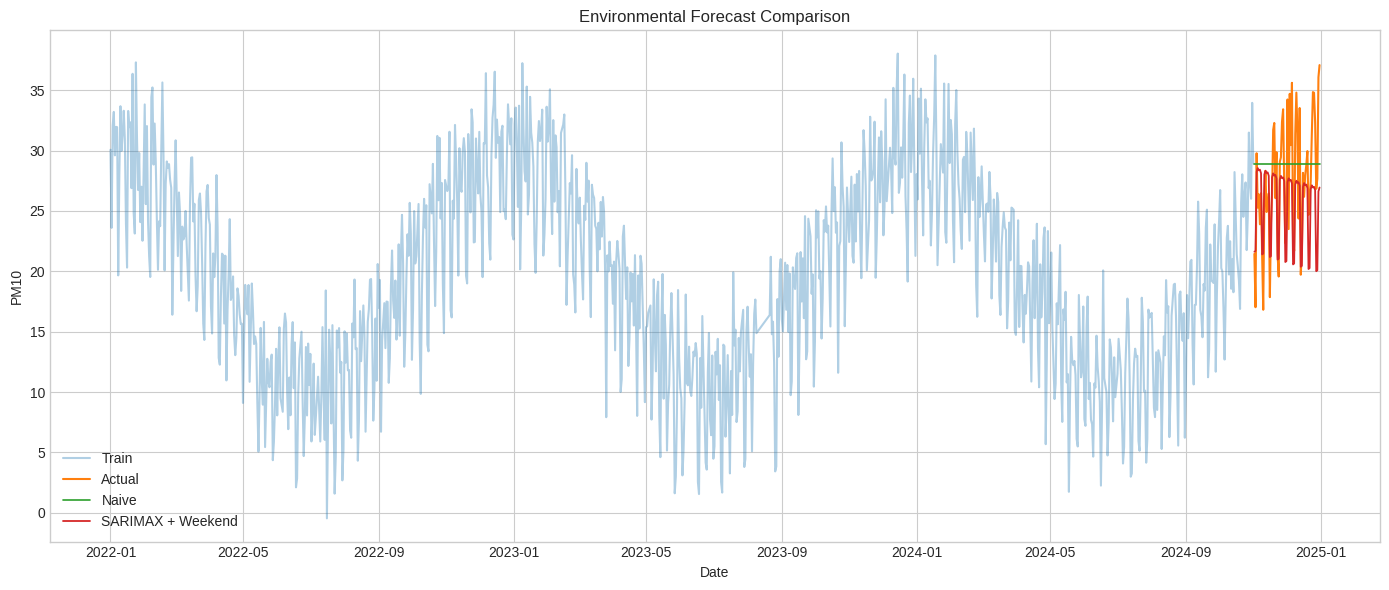

In [30]:
# ============================================
# 30. Environmental forecast comparison plot
# ============================================

plt.figure(figsize=(14, 6))
plt.plot(env_train.index, env_train["PM10_interp"], label="Train", alpha=0.35)
plt.plot(env_test.index, env_test["PM10_interp"], label="Actual", linewidth=1.5)
plt.plot(env_test.index, env_naive, label="Naive", linewidth=1.2)
plt.plot(env_test.index, env_forecast, label="SARIMAX + Weekend", linewidth=1.3)

plt.title("Environmental Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("PM10")
plt.legend()
plt.tight_layout()
plt.show()


# Part D. 도메인별 결과를 함께 해석하기

## 19. 도메인별 핵심 차이 정리
이번 노트북에서 확인한 핵심은 다음과 같습니다.

### 금융
- 가격 수준보다 로그수익률이 더 유용할 수 있다.
- 예측 대상이 평균이 아니라 변동성일 수 있다.
- GARCH 같은 분산 모형이 중요한 도메인이다.

### 경영
- 휴일, 프로모션, 캘린더 효과가 매우 중요하다.
- holiday effect를 넣지 않으면 peak를 놓치기 쉽다.
- Prophet 같은 실무형 도구가 유용할 수 있다.

### 환경
- 결측치 보간과 시간 인덱스 유지가 핵심이다.
- 주말/평일, 주간 주기 같은 외생 패턴이 중요할 수 있다.
- 고급 모델보다 전처리 품질이 성능을 좌우하는 경우가 많다.


## 20. 자주 발생하는 실수 (Common Mistakes)
이번 장에서 특히 자주 발생하는 실수는 다음과 같습니다.

1. **금융 가격을 그대로 예측 대상으로 두는 실수**  
   비정상성과 가짜 회귀 위험이 커질 수 있습니다.

2. **경영 데이터에서 휴일·이벤트를 무시하는 실수**  
   예측이 평균적으로는 맞아도 중요한 피크를 놓칠 수 있습니다.

3. **환경 데이터 결측을 무조건 삭제하는 실수**  
   시간축 연속성이 깨져 패턴 해석이 왜곡될 수 있습니다.

4. **도메인이 달라도 같은 모델을 기계적으로 반복하는 실수**  
   좋은 모델은 “항상 같은 모델”이 아니라 “도메인에 맞는 모델”입니다.


## 21. 실습 정리
이번 실습에서 확인한 핵심은 다음과 같습니다.

- 시계열 분석은 알고리즘 선택 이전에 도메인 이해가 중요하다.
- 금융 데이터는 수익률과 변동성, 경영 데이터는 이벤트와 휴일, 환경 데이터는 결측과 계절성이 핵심이다.
- 같은 성능 지표라도 도메인에 따라 해석 방식이 달라질 수 있다.
- 도메인별 전처리 전략이 모델링 성능만큼 중요하다.
- 결국 좋은 시계열 분석은 “가장 복잡한 모델”이 아니라 “가장 맥락에 맞는 분석 파이프라인”을 선택하는 데서 나온다.


## 22. 연습문제 (Exercises)

1. 금융 파트에서 TSLA 대신 다른 종목을 사용해 로그수익률과 ADF 결과를 비교하시오.

2. 경영 파트에서 holiday 효과를 더 크게 또는 더 작게 주었을 때, Prophet + Holidays의 성능 차이가 어떻게 달라지는지 비교하시오.

3. 환경 파트에서 결측치를 `dropna()`로 처리한 경우와 `interpolate()`로 처리한 경우의 차이를 그래프로 비교하시오.

4. 각 도메인에서 “예측 대상”이 무엇인지 다시 정리하시오.  
   (예: 금융은 가격인가, 수익률인가, 변동성인가?)

5. 세 도메인 중 하나를 선택해, 왜 해당 도메인에서는 특정 전처리가 특히 중요한지 자신의 언어로 설명하시오.
